## 1. Setup

In [1]:
import os
import json
import glob
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import cm
from PIL import Image
from IPython.display import display, HTML

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

In [2]:
# === Configuration ===
# Set the path to your explainability run directory
EXPLAIN_DIR = "../experiments/logs/explainability"

# List available runs
if os.path.exists(EXPLAIN_DIR):
    runs = sorted(os.listdir(EXPLAIN_DIR))
    print(f"Available runs ({len(runs)}):")
    for r in runs:
        print(f"  - {r}")
else:
    print(f"No explainability directory found at {EXPLAIN_DIR}")
    print("Run evaluation with --explainability True first.")
    runs = []

Available runs (8):
  - EVAL-libero_spatial-openvla-2026_02_20-08_41_55
  - EVAL-libero_spatial-openvla-2026_02_20-08_44_07
  - EVAL-libero_spatial-openvla-2026_02_20-08_59_02
  - EVAL-libero_spatial-openvla-2026_02_20-09_03_08
  - EVAL-libero_spatial-openvla-2026_02_20-09_18_59
  - EVAL-libero_spatial-openvla-2026_02_20-09_20_35
  - EVAL-libero_spatial-openvla-2026_02_20-09_22_34
  - EVAL-libero_spatial-openvla-2026_02_20-09_26_48


In [3]:
# Select run (use the latest by default)
RUN_ID = runs[-1] if runs else ""
RUN_DIR = os.path.join(EXPLAIN_DIR, RUN_ID)
print(f"Selected run: {RUN_ID}")
print(f"Run directory: {RUN_DIR}")

Selected run: EVAL-libero_spatial-openvla-2026_02_20-09_26_48
Run directory: ../experiments/logs/explainability/EVAL-libero_spatial-openvla-2026_02_20-09_26_48


In [4]:
# === Helper functions ===

def list_tasks(run_dir):
    """List all task directories in a run."""
    tasks = sorted(glob.glob(os.path.join(run_dir, "task_*")))
    return [(os.path.basename(t), t) for t in tasks]

def list_episodes(task_dir):
    """List all episode directories in a task."""
    episodes = sorted(glob.glob(os.path.join(task_dir, "episode_*")))
    return [(os.path.basename(e), e) for e in episodes]

def list_steps(episode_dir):
    """List all step directories in an episode."""
    steps = sorted(glob.glob(os.path.join(episode_dir, "step_*")),
                   key=lambda x: int(os.path.basename(x).split('_')[1]))
    return [(os.path.basename(s), s) for s in steps]

def load_step_data(step_dir):
    """Load all explainability data for a single step."""
    data = {}
    
    # Metadata
    meta_path = os.path.join(step_dir, "metadata.json")
    if os.path.exists(meta_path):
        with open(meta_path) as f:
            data['metadata'] = json.load(f)
    
    # Input image
    img_path = os.path.join(step_dir, "input_image.png")
    if os.path.exists(img_path):
        data['input_image'] = Image.open(img_path)
    
    # Action probabilities
    probs_path = os.path.join(step_dir, "action_probs.json")
    if os.path.exists(probs_path):
        with open(probs_path) as f:
            data['action_probs'] = json.load(f)
    
    # Attention maps
    attn_path = os.path.join(step_dir, "attention_maps.npz")
    if os.path.exists(attn_path):
        data['attention_maps'] = dict(np.load(attn_path))
    
    # Logit lens
    lens_path = os.path.join(step_dir, "logit_lens.json")
    if os.path.exists(lens_path):
        with open(lens_path) as f:
            data['logit_lens'] = json.load(f)
    
    # GradCAM
    gradcam_path = os.path.join(step_dir, "gradcam.npz")
    if os.path.exists(gradcam_path):
        data['gradcam'] = dict(np.load(gradcam_path))
    
    # Projector features
    proj_path = os.path.join(step_dir, "projector_features.npz")
    if os.path.exists(proj_path):
        data['projector_features'] = np.load(proj_path)['features']
    
    return data

def load_episode_data(episode_dir):
    """Load data for all steps in an episode."""
    steps = list_steps(episode_dir)
    episode_data = []
    for step_name, step_dir in steps:
        step_data = load_step_data(step_dir)
        step_data['step_name'] = step_name
        episode_data.append(step_data)
    return episode_data

# Show available structure
if RUN_ID:
    tasks = list_tasks(RUN_DIR)
    print(f"\nTasks ({len(tasks)}):")
    for tname, tdir in tasks:
        episodes = list_episodes(tdir)
        total_steps = sum(len(list_steps(edir)) for _, edir in episodes)
        print(f"  {tname}: {len(episodes)} episodes, {total_steps} total steps")


Tasks (10):
  task_0: 1 episodes, 9 total steps
  task_1: 1 episodes, 11 total steps
  task_2: 1 episodes, 22 total steps
  task_3: 1 episodes, 9 total steps
  task_4: 1 episodes, 13 total steps
  task_5: 1 episodes, 9 total steps
  task_6: 1 episodes, 11 total steps
  task_7: 1 episodes, 22 total steps
  task_8: 1 episodes, 20 total steps
  task_9: 1 episodes, 12 total steps


In [5]:
# === Select a specific episode to analyze ===
# Modify these to select different task/episode
TASK_IDX = 0
EPISODE_IDX = 0

if tasks:
    task_name, task_dir = tasks[TASK_IDX]
    episodes = list_episodes(task_dir)
    if episodes:
        ep_name, ep_dir = episodes[EPISODE_IDX]
        episode_data = load_episode_data(ep_dir)
        print(f"Loaded {len(episode_data)} steps from {task_name}/{ep_name}")
        if episode_data and 'metadata' in episode_data[0]:
            print(f"Task: {episode_data[0]['metadata'].get('task_description', 'N/A')}")
    else:
        print("No episodes found")
        episode_data = []
else:
    episode_data = []

Loaded 9 steps from task_0/episode_0
Task: pick up the black bowl between the plate and the ramekin and place it on the plate


## 3. Attention Heatmaps

Visualize cross-modal attention from the last (action-predicting) token to vision patches.
Shows where the model "looks" when deciding on actions.

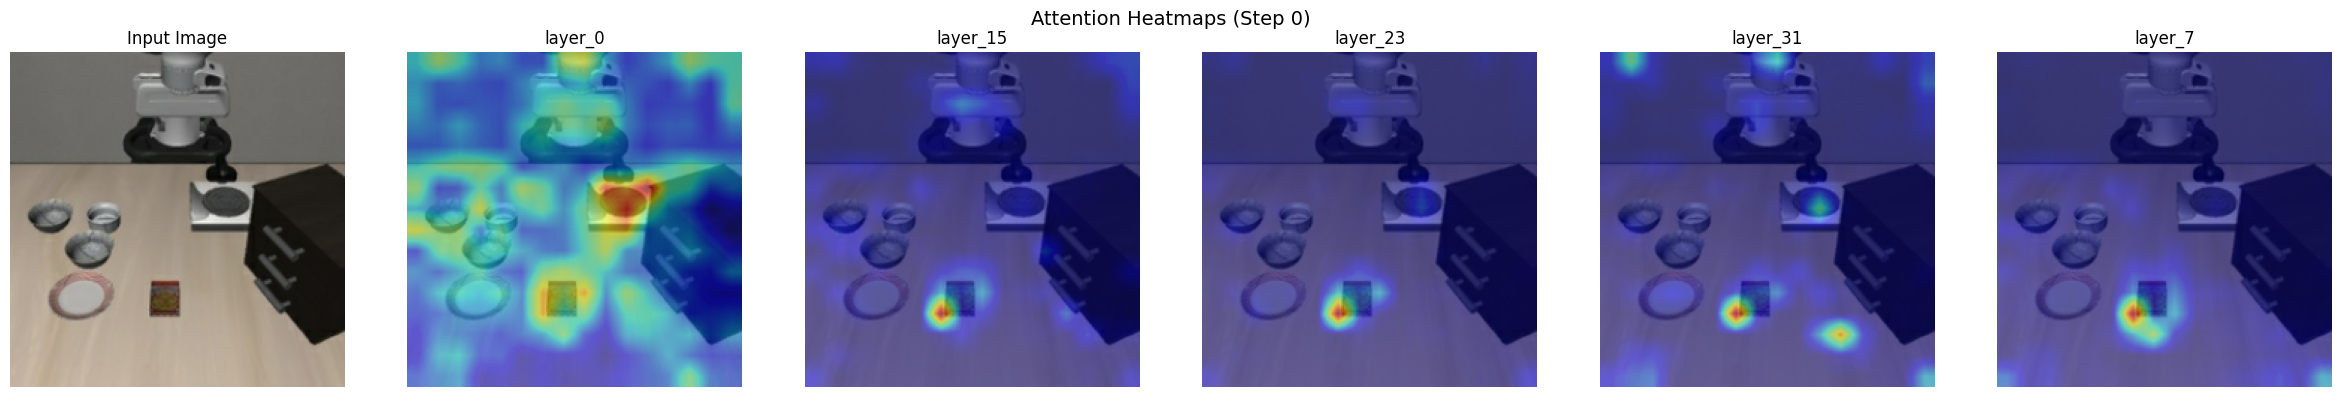

In [9]:
# === Single step attention heatmaps across layers ===
STEP_TO_SHOW = 0

if episode_data and 'attention_maps' in episode_data[STEP_TO_SHOW]:
    step = episode_data[STEP_TO_SHOW]
    attn_maps = step['attention_maps']
    img = step.get('input_image')
    
    layer_names = sorted(attn_maps.keys())
    n_layers = len(layer_names)
    
    fig, axes = plt.subplots(1, n_layers + 1, figsize=(4 * (n_layers + 1), 4))
    
    # Original image
    if img is not None:
        axes[0].imshow(img)
        axes[0].set_title('Input Image')
        axes[0].axis('off')
    
    # Attention heatmaps
    for idx, layer_name in enumerate(layer_names):
        attn_map = attn_maps[layer_name]
        ax = axes[idx + 1]
        if img is not None:
            attn_resized = np.array(
                Image.fromarray((attn_map * 255).astype(np.uint8)).resize(
                    img.size, Image.BILINEAR)) / 255.0
            ax.imshow(img)
            ax.imshow(attn_resized, cmap='jet', alpha=0.5)
        else:
            ax.imshow(attn_map, cmap='jet')
        ax.set_title(layer_name)
        ax.axis('off')
    
    plt.suptitle(f'Attention Heatmaps (Step {STEP_TO_SHOW})', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No attention map data available.")

In [10]:
# === Attention evolution over timesteps (animated GIF) ===
steps_with_attn = [s for s in episode_data if 'attention_maps' in s]

if len(steps_with_attn) > 1:
    # Use the first available layer
    layer_name = sorted(steps_with_attn[0]['attention_maps'].keys())[0]
    print(f"Creating attention animation for {layer_name}...")
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    def update(frame_idx):
        ax.clear()
        step = steps_with_attn[frame_idx]
        attn_map = step['attention_maps'][layer_name]
        img = step.get('input_image')
        
        if img is not None:
            attn_resized = np.array(
                Image.fromarray((attn_map * 255).astype(np.uint8)).resize(
                    img.size, Image.BILINEAR)) / 255.0
            ax.imshow(img)
            ax.imshow(attn_resized, cmap='jet', alpha=0.5)
        else:
            ax.imshow(attn_map, cmap='jet')
        
        step_idx = step.get('metadata', {}).get('step_idx', frame_idx)
        ax.set_title(f'{layer_name} - Step {step_idx}')
        ax.axis('off')
    
    ani = animation.FuncAnimation(fig, update, frames=len(steps_with_attn), interval=500)
    
    # Save as GIF
    gif_path = os.path.join(RUN_DIR, 'attention_animation.gif')
    ani.save(gif_path, writer='pillow', fps=2)
    plt.close(fig)
    print(f"Saved attention animation to {gif_path}")
    
    # Display in notebook
    display(HTML(f'<img src="{gif_path}" />'))
else:
    print("Need at least 2 steps with attention data for animation.")

Creating attention animation for layer_0...
Saved attention animation to ../experiments/logs/explainability/EVAL-libero_spatial-openvla-2026_02_20-09_26_48/attention_animation.gif


## 5. GradCAM Saliency

Gradient-based importance maps showing which image regions causally influence the predicted action.
Compare with attention-based heatmaps.

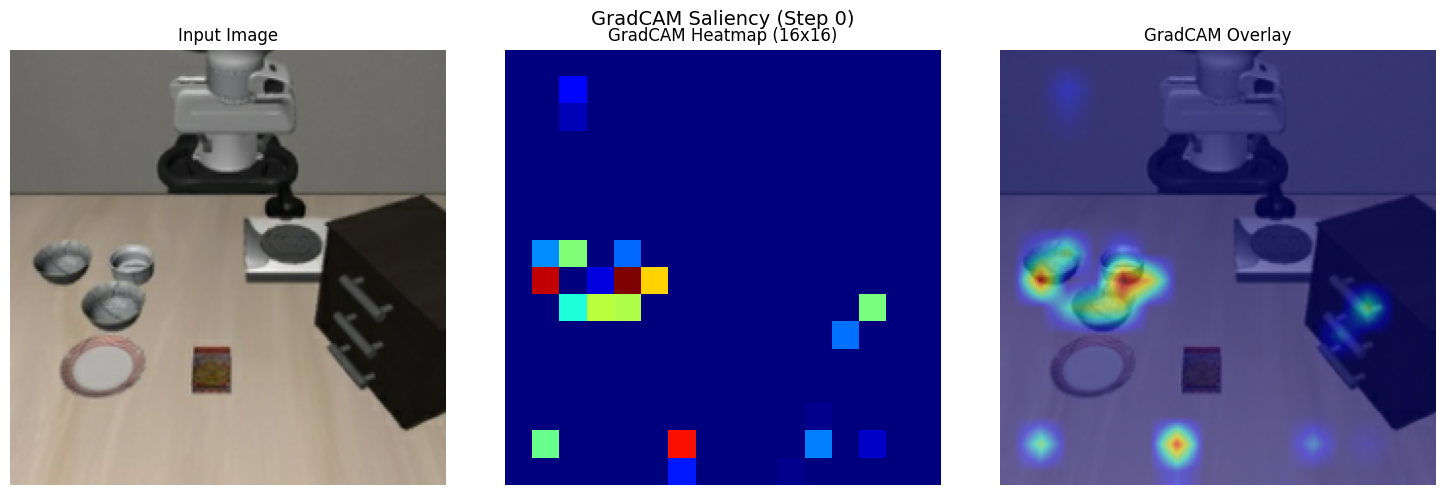

In [13]:
# === Single step GradCAM visualization ===
STEP_TO_SHOW = 0

if episode_data and 'gradcam' in episode_data[STEP_TO_SHOW]:
    step = episode_data[STEP_TO_SHOW]
    cam_2d = step['gradcam']['cam_2d']
    img = step.get('input_image')
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    if img is not None:
        axes[0].imshow(img)
        axes[0].set_title('Input Image')
        axes[0].axis('off')
        
        axes[1].imshow(cam_2d, cmap='jet')
        axes[1].set_title('GradCAM Heatmap (16x16)')
        axes[1].axis('off')
        
        cam_resized = np.array(
            Image.fromarray((cam_2d * 255).astype(np.uint8)).resize(
                img.size, Image.BILINEAR)) / 255.0
        axes[2].imshow(img)
        axes[2].imshow(cam_resized, cmap='jet', alpha=0.5)
        axes[2].set_title('GradCAM Overlay')
        axes[2].axis('off')
    
    plt.suptitle(f'GradCAM Saliency (Step {STEP_TO_SHOW})', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No GradCAM data available.")

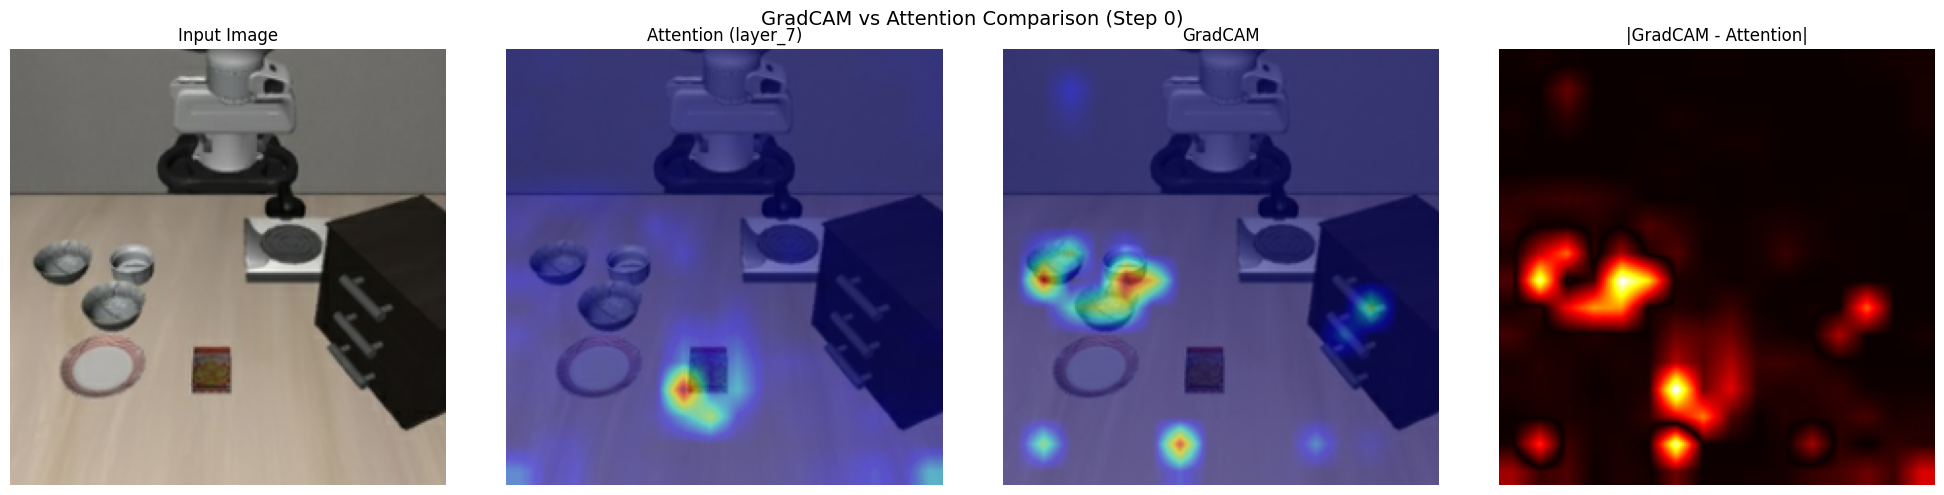

Pearson correlation between GradCAM and attention (layer_7): -0.025


In [14]:
# === Compare GradCAM with Attention heatmaps ===
STEP_TO_SHOW = 0

if (episode_data 
    and 'gradcam' in episode_data[STEP_TO_SHOW] 
    and 'attention_maps' in episode_data[STEP_TO_SHOW]):
    
    step = episode_data[STEP_TO_SHOW]
    cam_2d = step['gradcam']['cam_2d']
    attn_maps = step['attention_maps']
    img = step.get('input_image')
    
    # Use the last available attention layer for comparison
    last_layer = sorted(attn_maps.keys())[-1]
    attn_map = attn_maps[last_layer]
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    if img is not None:
        axes[0].imshow(img)
        axes[0].set_title('Input Image')
        axes[0].axis('off')
        
        # Attention overlay
        attn_resized = np.array(
            Image.fromarray((attn_map * 255).astype(np.uint8)).resize(
                img.size, Image.BILINEAR)) / 255.0
        axes[1].imshow(img)
        axes[1].imshow(attn_resized, cmap='jet', alpha=0.5)
        axes[1].set_title(f'Attention ({last_layer})')
        axes[1].axis('off')
        
        # GradCAM overlay
        cam_resized = np.array(
            Image.fromarray((cam_2d * 255).astype(np.uint8)).resize(
                img.size, Image.BILINEAR)) / 255.0
        axes[2].imshow(img)
        axes[2].imshow(cam_resized, cmap='jet', alpha=0.5)
        axes[2].set_title('GradCAM')
        axes[2].axis('off')
        
        # Difference map
        diff = np.abs(cam_resized - attn_resized)
        axes[3].imshow(diff, cmap='hot')
        axes[3].set_title('|GradCAM - Attention|')
        axes[3].axis('off')
    
    plt.suptitle(f'GradCAM vs Attention Comparison (Step {STEP_TO_SHOW})', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Compute correlation
    correlation = np.corrcoef(cam_2d.flatten(), attn_map.flatten())[0, 1]
    print(f"Pearson correlation between GradCAM and attention ({last_layer}): {correlation:.3f}")
else:
    print("Need both GradCAM and attention data for comparison.")